# Notebook Overview — Preprocess Images

## Purpose

This notebook preprocesses raw images from a **single selected dataset source** into a standardized format for downstream **feature extraction and classification**.

It resizes images, converts them to grayscale, standardizes format, and generates metadata describing the processed dataset.

This step operates on **one dataset source at a time** to ensure controlled execution within the Google Colab environment.

---

## Inputs

Supported dataset sources:

* ImageNet_1K_256  
* MS_COCO_2017  
* DiffusionDB  
* SDXL_Generated_10K  
* MidJourney  
* OpenImages *(excluded due to ZIP file size constraints)*  

💡 Raw datasets are provided as publicly accessible Google Drive ZIP archives and are downloaded automatically into the Colab runtime environment during execution.

Shared configuration:

* `src/project_config.py`

All raw images already follow the standardized filename convention:

* `rl_imgn_000001.png`  
* `ai_diff_000001.png`  

---

## Execution Model

* Preprocessing is performed **one source at a time**
* Dataset ZIP archives are downloaded from public Google Drive links
* ZIP files are stored temporarily in the local Colab runtime before extraction
* Images are extracted into a temporary working directory
* Each image undergoes:

  * Resize to **256 × 256**
  * Conversion to **grayscale**
  * Format standardization (PNG)

* Filenames are **preserved exactly** from raw input
* No dataset mixing or splitting occurs in this notebook
* Processing is deterministic and repeatable

---

## Outputs

For the selected dataset source:

**Preprocessed Images**  
`data/preprocessed/<dataset>/images/`  
Images are resized, converted to grayscale, and saved using the original filenames.

**Preprocessed Metadata CSV**  
`metadata/preprocessed/<dataset>_preprocessed_metadata.csv`  
Records one entry per image, including:

* filename  
* class label  
* source dataset  
* original image dimensions  
* processed image path

---

### 🔷 Step 1 — Environment Setup and Configuration

- Initialize the Colab runtime environment for public tutorial execution
- Clone the GitHub repository if needed
- Verify required repository structure and configuration file
- Add the project `src` directory to the Python path
- Dynamically import `project_config.py`
- Extract notebook-specific configuration values
- Configure local runtime directories for ZIP downloads and extraction
- Create required output directories if they do not exist
- Optionally display key project paths when `VERBOSE=True`

---

In [ ]:
# ============================================
# Step 1: Environment Setup and Configuration
# ============================================

# ============================================
# USER CONFIGURATION — EDIT THIS SECTION ONLY
# ============================================

VERBOSE = True   # User toggle (True or False)

# ============================================
# END USER CONFIGURATION
# ============================================

# -------------------------------------------------
# Public tutorial mode:
# ZIP files are downloaded from public Google Drive
# file IDs into the Colab runtime environment.
# -------------------------------------------------

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import os
import sys
import zipfile
import shutil
import importlib.util

import gdown

import pandas as pd
from PIL import Image

# -------------------------------------------------
# Define project locations
# -------------------------------------------------
BASE_DIR = "/content/dip-ai-image-detection"
PROJECT_SRC_DIR = f"{BASE_DIR}/src"
CONFIG_FILE = f"{PROJECT_SRC_DIR}/project_config.py"

# -------------------------------------------------
# Public runtime ZIP download location
# -------------------------------------------------
LOCAL_WORK_DIR = "/content"
LOCAL_RAW_RELEASES_DIR = f"{LOCAL_WORK_DIR}/raw_releases"

print("Initializing environment...")

# -------------------------------------------------
# Clone repo if not already present
# -------------------------------------------------
if not os.path.isdir(BASE_DIR):
    print("Cloning repository...")
    !git clone -q https://github.com/pgailinas/dip-ai-image-detection.git
else:
    print("Repository already exists. Skipping clone.")

# -------------------------------------------------
# Verify required repository structure
# -------------------------------------------------
if not os.path.isdir(PROJECT_SRC_DIR):
    raise FileNotFoundError(f"Missing directory: {PROJECT_SRC_DIR}")

if not os.path.isfile(CONFIG_FILE):
    raise FileNotFoundError(f"Missing file: {CONFIG_FILE}")

# -------------------------------------------------
# Add src to Python path
# -------------------------------------------------
if PROJECT_SRC_DIR not in sys.path:
    sys.path.insert(0, PROJECT_SRC_DIR)

# -------------------------------------------------
# Dynamically import project configuration
# -------------------------------------------------
spec = importlib.util.spec_from_file_location("project_config", CONFIG_FILE)
cfg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# -------------------------------------------------
# Pull only what this notebook actually uses
# -------------------------------------------------
DATASET_CODES = cfg.DATASET_CODES
SOURCE_FOLDER_NAMES = cfg.SOURCE_FOLDER_NAMES
SOURCE_LABEL_MAP = cfg.SOURCE_LABEL_MAP

PROCESSED_DATA_DIR = cfg.PROCESSED_DATA_DIR
PREPROCESSED_DIRS = cfg.PREPROCESSED_DIRS
PREPROCESSED_METADATA_DIR = cfg.PREPROCESSED_METADATA_DIR
PREPROCESSED_METADATA_FILES = cfg.PREPROCESSED_METADATA_FILES
PREPROCESSED_METADATA_COLUMNS = cfg.PREPROCESSED_METADATA_COLUMNS

TARGET_SIZE = cfg.TARGET_SIZE
OUTPUT_IMAGE_FORMAT = cfg.OUTPUT_IMAGE_FORMAT
OUTPUT_COLOR_MODE = cfg.OUTPUT_COLOR_MODE
OUTPUT_FILE_EXTENSION = cfg.OUTPUT_FILE_EXTENSION

PUBLIC_RAW_ZIP_FILE_IDS = cfg.PUBLIC_RAW_ZIP_FILE_IDS
PUBLIC_RAW_ZIP_SIZES_GB = cfg.PUBLIC_RAW_ZIP_SIZES_GB

# -------------------------------------------------
# Ensure required output directories exist
# -------------------------------------------------
os.makedirs(cfg.DATA_DIR, exist_ok=True)
os.makedirs(cfg.PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(cfg.METADATA_DIR, exist_ok=True)
os.makedirs(cfg.PREPROCESSED_METADATA_DIR, exist_ok=True)

# -------------------------------------------------
# Ensure local runtime ZIP directory exists
# -------------------------------------------------
os.makedirs(LOCAL_RAW_RELEASES_DIR, exist_ok=True)

print("\nEnvironment setup complete.\n")

# -------------------------------------------------
# Optional verbose display of key paths
# -------------------------------------------------
if VERBOSE:
    print(f"BASE_DIR                  : {cfg.BASE_DIR}")
    print(f"PROJECT_SRC_DIR           : {PROJECT_SRC_DIR}")
    print(f"LOCAL_RAW_RELEASES_DIR    : {LOCAL_RAW_RELEASES_DIR}")
    print(f"PROCESSED_DATA_DIR        : {PROCESSED_DATA_DIR}")
    print(f"PREPROCESSED_METADATA_DIR : {PREPROCESSED_METADATA_DIR}")



Initializing environment...
Cloning repository...

Environment setup complete.

BASE_DIR                  : /content/dip-ai-image-detection
PROJECT_SRC_DIR           : /content/dip-ai-image-detection/src
LOCAL_RAW_RELEASES_DIR    : /content/raw_releases
PROCESSED_DATA_DIR        : /content/dip-ai-image-detection/data/preprocessed
PREPROCESSED_METADATA_DIR : /content/dip-ai-image-detection/metadata/preprocessed


### 🔷 Step 2 — User Source Selection (with ZIP sizes)

- Define publicly accessible dataset ZIP archives for preprocessing
- Configure public Google Drive file IDs and ZIP size metadata
- Display each available dataset source with its ZIP size in GB
- Exclude OpenImages from selection because of size constraints
- Prompt the user to select one dataset source
- Validate the selected source option and public Google Drive file ID
- Extract source-specific values used by later preprocessing steps
- Display the selected source configuration

---

In [ ]:
# ============================================
# Step 2: User Source Selection (with ZIP sizes)
# ============================================

# -------------------------------------------------
# Available dataset source options
# -------------------------------------------------
# OpenImages is excluded from preprocessing selection
# because the ZIP file is too large for this workflow.
# -------------------------------------------------

SOURCE_OPTIONS = {
    "1": {
        "source_name": "imagenet",
        "display_name": "ImageNet",
        "dataset_folder": SOURCE_FOLDER_NAMES["imagenet"],
        "zip_filename": "ImageNet_1K_256.zip",
        "drive_file_id": PUBLIC_RAW_ZIP_FILE_IDS["imagenet"],
        "zip_size_gb": PUBLIC_RAW_ZIP_SIZES_GB["imagenet"],
        "dataset_code": DATASET_CODES["imagenet"],
        "class_label": SOURCE_LABEL_MAP["imagenet"],
    },
    "2": {
        "source_name": "coco",
        "display_name": "MS COCO",
        "dataset_folder": SOURCE_FOLDER_NAMES["coco"],
        "zip_filename": "MS_COCO_2017.zip",
        "drive_file_id": PUBLIC_RAW_ZIP_FILE_IDS["coco"],
        "zip_size_gb": PUBLIC_RAW_ZIP_SIZES_GB["coco"],
        "dataset_code": DATASET_CODES["coco"],
        "class_label": SOURCE_LABEL_MAP["coco"],
    },
    "3": {
        "source_name": "diffusiondb",
        "display_name": "DiffusionDB",
        "dataset_folder": SOURCE_FOLDER_NAMES["diffusiondb"],
        "zip_filename": "DiffusionDB.zip",
        "drive_file_id": PUBLIC_RAW_ZIP_FILE_IDS["diffusiondb"],
        "zip_size_gb": PUBLIC_RAW_ZIP_SIZES_GB["diffusiondb"],
        "dataset_code": DATASET_CODES["diffusiondb"],
        "class_label": SOURCE_LABEL_MAP["diffusiondb"],
    },
    "4": {
        "source_name": "sdxl",
        "display_name": "SDXL",
        "dataset_folder": SOURCE_FOLDER_NAMES["sdxl"],
        "zip_filename": "SDXL_Generated_10K.zip",
        "drive_file_id": PUBLIC_RAW_ZIP_FILE_IDS["sdxl"],
        "zip_size_gb": PUBLIC_RAW_ZIP_SIZES_GB["sdxl"],
        "dataset_code": DATASET_CODES["sdxl"],
        "class_label": SOURCE_LABEL_MAP["sdxl"],
    },
    "5": {
        "source_name": "midjourney",
        "display_name": "Midjourney",
        "dataset_folder": SOURCE_FOLDER_NAMES["midjourney"],
        "zip_filename": "Midjourney.zip",
        "drive_file_id": PUBLIC_RAW_ZIP_FILE_IDS["midjourney"],
        "zip_size_gb": PUBLIC_RAW_ZIP_SIZES_GB["midjourney"],
        "dataset_code": DATASET_CODES["midjourney"],
        "class_label": SOURCE_LABEL_MAP["midjourney"],
    },
}

# -------------------------------------------------
# Display choices with configured ZIP sizes
# -------------------------------------------------

print("\nZIP files will be downloaded into the temporary Colab runtime environment.")
print("Select one dataset source to preprocess:\n")

for key, info in SOURCE_OPTIONS.items():
    size_gb = info["zip_size_gb"]
    size_str = f"{size_gb:.2f} GB"

    # Flag unusually large ZIP files
    warning = " ⚠️ LARGE" if size_gb > 5 else ""

    print(f"{key} - {info['display_name']} ({size_str}){warning}")

print("\nNote: OpenImages (~22GB) is excluded due to size constraints.")

# -------------------------------------------------
# User selection
# -------------------------------------------------

user_choice = input("\nEnter the number of the source to preprocess: ").strip()

# Validate menu selection
if user_choice not in SOURCE_OPTIONS:
    raise ValueError("Invalid selection. Please rerun and choose a valid option.")

selected_source = SOURCE_OPTIONS[user_choice]

# -------------------------------------------------
# Extract selected values
# -------------------------------------------------

SOURCE_NAME = selected_source["source_name"]
DISPLAY_NAME = selected_source["display_name"]
DATASET_FOLDER = selected_source["dataset_folder"]
ZIP_FILENAME = selected_source["zip_filename"]
DRIVE_FILE_ID = selected_source["drive_file_id"]
ZIP_SIZE_GB = selected_source["zip_size_gb"]
DATASET_CODE = selected_source["dataset_code"]
CLASS_LABEL = selected_source["class_label"]

# -------------------------------------------------
# Validate public Drive file ID
# -------------------------------------------------

if "PASTE_" in DRIVE_FILE_ID or not DRIVE_FILE_ID.strip():
    raise ValueError(
        f"Missing public Google Drive file ID for selected source: {SOURCE_NAME}"
    )

# -------------------------------------------------
# Final confirmation
# -------------------------------------------------

print("\nSelected source configuration:")
print(f"  Display name   : {DISPLAY_NAME}")
print(f"  Dataset folder : {DATASET_FOLDER}")
print(f"  ZIP filename   : {ZIP_FILENAME}")
print(f"  ZIP size       : {ZIP_SIZE_GB:.2f} GB")
print(f"  Dataset code   : {DATASET_CODE}")
print(f"  Class label    : {CLASS_LABEL}")




ZIP files will be downloaded into the temporary Colab runtime environment.
Select one dataset source to preprocess:

1 - ImageNet (0.33 GB)
2 - MS COCO (1.50 GB)
3 - DiffusionDB (1.80 GB)
4 - SDXL (3.70 GB)
5 - Midjourney (3.80 GB)

Note: OpenImages (~22GB) is excluded due to size constraints.

Enter the number of the source to preprocess: 1

Selected source configuration:
  Display name   : ImageNet
  Dataset folder : ImageNet_1K_256
  ZIP filename   : ImageNet_1K_256.zip
  ZIP size       : 0.33 GB
  Dataset code   : imgn
  Class label    : rl


### 🔷 Step 3 — Define ZIP, Extraction, and Output Paths

- Define the local Colab runtime ZIP download path for the selected dataset source
- Define temporary extraction directories within the Colab runtime
- Define output directories for processed images
- Define the output path for the preprocessed metadata CSV
- Create all required directories if they do not exist
- Remove any existing processed images, metadata, and temporary ZIP files for a clean rebuild
- Optionally display all resolved paths when `VERBOSE=True`

---


In [ ]:
# ============================================
# Step 3: Define ZIP, Extraction, and Output Paths
# ============================================

# -------------------------------------------------
# Local ZIP path in Colab runtime
# -------------------------------------------------
# ZIP file will be downloaded from public Google
# Drive into the temporary Colab runtime.
local_zip_path = os.path.join(LOCAL_RAW_RELEASES_DIR, ZIP_FILENAME)

# -------------------------------------------------
# Local extraction paths in Colab runtime
# -------------------------------------------------
# Root directory for extracted raw datasets
# (temporary workspace)
local_extract_root = os.path.join(LOCAL_WORK_DIR, "raw_extracted")

# Dataset-specific extraction directory
local_extract_dir = os.path.join(local_extract_root, DATASET_FOLDER)

# Expected image directory after extraction
local_image_dir = os.path.join(local_extract_dir, "images")

# -------------------------------------------------
# Output paths for processed images
# -------------------------------------------------
# Directory for preprocessed dataset outputs
processed_source_dir = PREPROCESSED_DIRS[SOURCE_NAME]

# Directory for processed images
processed_image_dir = os.path.join(
    processed_source_dir,
    "images"
)

# -------------------------------------------------
# Output path for metadata CSV
# -------------------------------------------------
# Directory and file path for preprocessed metadata
metadata_preprocessed_dir = PREPROCESSED_METADATA_DIR
metadata_csv_path = PREPROCESSED_METADATA_FILES[SOURCE_NAME]

# -------------------------------------------------
# Create required output directories
# -------------------------------------------------
# Ensure all required directories exist before processing
os.makedirs(LOCAL_RAW_RELEASES_DIR, exist_ok=True)
os.makedirs(local_extract_root, exist_ok=True)
os.makedirs(processed_source_dir, exist_ok=True)
os.makedirs(processed_image_dir, exist_ok=True)
os.makedirs(metadata_preprocessed_dir, exist_ok=True)

# -------------------------------------------------
# Clean previous outputs for this source
# -------------------------------------------------
# Remove previously processed images to ensure clean rebuild
if os.path.exists(processed_image_dir):
    if VERBOSE:
        print(f"Clearing existing processed images: {processed_image_dir}")
    shutil.rmtree(processed_image_dir)

# Recreate processed image directory
os.makedirs(processed_image_dir, exist_ok=True)

# Remove existing metadata CSV for this source
if os.path.exists(metadata_csv_path):
    if VERBOSE:
        print(f"Removing existing metadata file: {metadata_csv_path}")
    os.remove(metadata_csv_path)

# -------------------------------------------------
# Remove existing local ZIP copy (optional cleanup)
# -------------------------------------------------
if os.path.exists(local_zip_path):
    if VERBOSE:
        print(f"Removing existing local ZIP file: {local_zip_path}")
    os.remove(local_zip_path)

# -------------------------------------------------
# Display resolved paths
# -------------------------------------------------
# Optional verbose display of all key paths
if VERBOSE:
    print("Resolved paths:")
    print(f"  Local ZIP path          : {local_zip_path}")
    print(f"  Local extract root      : {local_extract_root}")
    print(f"  Local extract dir       : {local_extract_dir}")
    print(f"  Local image dir         : {local_image_dir}")
    print(f"  Processed source dir    : {processed_source_dir}")
    print(f"  Processed image dir     : {processed_image_dir}")
    print(f"  Metadata output CSV     : {metadata_csv_path}")



Clearing existing processed images: /content/dip-ai-image-detection/data/preprocessed/ImageNet_1K_256/images
Removing existing metadata file: /content/dip-ai-image-detection/metadata/preprocessed/imgn_preprocessed_metadata.csv
Resolved paths:
  Local ZIP path          : /content/raw_releases/ImageNet_1K_256.zip
  Local extract root      : /content/raw_extracted
  Local extract dir       : /content/raw_extracted/ImageNet_1K_256
  Local image dir         : /content/raw_extracted/ImageNet_1K_256/images
  Processed source dir    : /content/dip-ai-image-detection/data/preprocessed/ImageNet_1K_256
  Processed image dir     : /content/dip-ai-image-detection/data/preprocessed/ImageNet_1K_256/images
  Metadata output CSV     : /content/dip-ai-image-detection/metadata/preprocessed/imgn_preprocessed_metadata.csv


### 🔷 Step 4 — Download and Extract Selected ZIP File

- Download the selected dataset ZIP archive from public Google Drive
- Store the ZIP file in the temporary Colab runtime environment
- Verify that the ZIP file was successfully downloaded
- Remove any existing extracted dataset for a clean rebuild
- Extract the ZIP file into the local working directory
- Inspect the extracted directory structure
- Locate candidate directories containing image files
- Select the directory with the highest number of valid images
- Validate that image files were successfully extracted
- Display the selected image directory and file count

---

In [ ]:
# ============================================
# Step 4: Download and Extract Selected ZIP File
# ============================================

# -------------------------------------------------
# Download selected ZIP from public Google Drive
# -------------------------------------------------
download_url = f"https://drive.google.com/uc?id={DRIVE_FILE_ID}"

print(f"Downloading ZIP from public Google Drive:")
print(f"  Dataset  : {DISPLAY_NAME}")
print(f"  File ID  : {DRIVE_FILE_ID}")
print(f"  Output   : {local_zip_path}")

gdown.download(
    download_url,
    local_zip_path,
    quiet=False
)

# -------------------------------------------------
# Verify local ZIP download
# -------------------------------------------------
if not os.path.exists(local_zip_path):
    raise FileNotFoundError(f"ZIP file was not downloaded: {local_zip_path}")

zip_size_gb = os.path.getsize(local_zip_path) / (1024 ** 3)
print(f"\nZIP file downloaded: {local_zip_path}")
print(f"ZIP size: {zip_size_gb:.2f} GB")

# -------------------------------------------------
# Remove old extracted copy of this dataset, if present
# -------------------------------------------------
if os.path.exists(local_extract_dir):
    print(f"Removing existing extracted folder: {local_extract_dir}")
    shutil.rmtree(local_extract_dir)

# -------------------------------------------------
# Extract ZIP locally
# -------------------------------------------------
print(f"Extracting ZIP to: {local_extract_root}")

with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
    zip_ref.extractall(local_extract_root)

print("Extraction complete.")

# -------------------------------------------------
# Inspect extracted structure
# -------------------------------------------------
print("\nTop-level extracted contents:")
top_level_items = sorted(os.listdir(local_extract_root))
for item in top_level_items[:20]:
    print(f"  {item}")
if len(top_level_items) > 20:
    print(f"  ... ({len(top_level_items) - 20} more items)")

# -------------------------------------------------
# Locate folder containing images
# -------------------------------------------------
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

candidate_dirs = []

# 1. Expected path: <dataset>/images
expected_image_dir = os.path.join(local_extract_dir, "images")
if os.path.isdir(expected_image_dir):
    candidate_dirs.append(expected_image_dir)

# 2. Dataset folder may directly contain images
if os.path.isdir(local_extract_dir):
    candidate_dirs.append(local_extract_dir)

# 3. Recursively search for directories containing image files
for root, dirs, files in os.walk(local_extract_root):
    image_count = sum(1 for f in files if f.lower().endswith(valid_extensions))
    if image_count > 0:
        candidate_dirs.append(root)

# Remove duplicates while preserving order
seen = set()
candidate_dirs = [d for d in candidate_dirs if not (d in seen or seen.add(d))]

# Ensure at least one candidate directory exists
if not candidate_dirs:
    raise FileNotFoundError(
        "No directory containing image files was found after extraction."
    )

# -------------------------------------------------
# Select best image directory
# -------------------------------------------------
best_dir = None
best_count = 0

for d in candidate_dirs:
    try:
        count = sum(
            1 for f in os.listdir(d)
            if os.path.isfile(os.path.join(d, f)) and f.lower().endswith(valid_extensions)
        )
    except Exception:
        count = 0

    print(f"Candidate image directory: {d}  --> {count} image files")

    if count > best_count:
        best_count = count
        best_dir = d

# Validate selected directory
if best_dir is None or best_count == 0:
    raise FileNotFoundError(
        "A directory was found, but no valid image files were located."
    )

# Final selected image directory
local_image_dir = best_dir

# Collect extracted image file list
extracted_files = sorted([
    f for f in os.listdir(local_image_dir)
    if os.path.isfile(os.path.join(local_image_dir, f))
    and f.lower().endswith(valid_extensions)
])

print(f"\nSelected image directory: {local_image_dir}")
print(f"Number of extracted image files found: {len(extracted_files)}")

# Ensure images were found
if len(extracted_files) == 0:
    raise ValueError("No valid image files were found in the selected image directory.")

# -------------------------------------------------
# Final confirmation
# -------------------------------------------------
print(f"Local ZIP file      : {local_zip_path}")
print(f"Extraction root     : {local_extract_root}")
print(f"Selected image dir  : {local_image_dir}")



  Dataset  : ImageNet
  File ID  : 1ctpQS6GN4uo4OtqJWoOML00MXg6QIVeL
  Output   : /content/raw_releases/ImageNet_1K_256.zip


Downloading...
From (original): https://drive.google.com/uc?id=1ctpQS6GN4uo4OtqJWoOML00MXg6QIVeL
From (redirected): https://drive.google.com/uc?id=1ctpQS6GN4uo4OtqJWoOML00MXg6QIVeL&confirm=t&uuid=a900bb9f-ef5a-4484-ba8e-920c166b72f0
To: /content/raw_releases/ImageNet_1K_256.zip
100%|██████████| 331M/331M [00:04<00:00, 73.0MB/s]



ZIP file downloaded: /content/raw_releases/ImageNet_1K_256.zip
ZIP size: 0.31 GB
Extracting ZIP to: /content/raw_extracted
Extraction complete.

Top-level extracted contents:
  ImageNet_1K_256
Candidate image directory: /content/raw_extracted/ImageNet_1K_256  --> 3000 image files

Selected image directory: /content/raw_extracted/ImageNet_1K_256
Number of extracted image files found: 3000
Local ZIP file      : /content/raw_releases/ImageNet_1K_256.zip
Extraction root     : /content/raw_extracted
Selected image dir  : /content/raw_extracted/ImageNet_1K_256


### 🔷 Step 5 — Initialize Preprocessing Parameters

- Load preprocessing settings from `project_config.py`
- Define supported input image file extensions
- Initialize processing counters for the current run
- Initialize the metadata record container
- Set the starting filename index for standardized outputs
- Display the selected source configuration and preprocessing settings

---

In [ ]:
# ============================================
# Step 5: Initialize Preprocessing Parameters
# ============================================

# -------------------------------------------------
# Preprocessing settings from project_config.py
# -------------------------------------------------
# Use centralized configuration values for image resizing and output format
target_size = TARGET_SIZE
output_format = OUTPUT_IMAGE_FORMAT
output_color_mode = OUTPUT_COLOR_MODE
output_extension = OUTPUT_FILE_EXTENSION

# Supported input image file extensions
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

# -------------------------------------------------
# Initialize processing counters (per run)
# -------------------------------------------------
# Total number of extracted image files discovered in Step 4
total_files_found = len(extracted_files)

# Counters updated during preprocessing
processed_count = 0
skipped_invalid_count = 0
error_count = 0

# No skipped-existing case is expected because this notebook rebuilds output fresh
skipped_existing_count = 0

# -------------------------------------------------
# Initialize metadata container
# -------------------------------------------------
# Stores one metadata record per successfully processed image
metadata_records = []

# -------------------------------------------------
# Initialize filename index (always start fresh)
# -------------------------------------------------
# Used to generate standardized output filenames
current_index = 1

# -------------------------------------------------
# Display initialization summary
# -------------------------------------------------
print("Preprocessing parameters initialized:")
print(f"  Selected source       : {DISPLAY_NAME}")
print(f"  Dataset code          : {DATASET_CODE}")
print(f"  Class label           : {CLASS_LABEL}")
print(f"  Target size           : {target_size}")
print(f"  Output format         : {output_format}")
print(f"  Output color mode     : {output_color_mode}")
print(f"  Output extension      : {output_extension}")
print(f"  Extracted files found : {total_files_found}")
print(f"  Starting index        : {current_index}")



Preprocessing parameters initialized:
  Selected source       : ImageNet
  Dataset code          : imgn
  Class label           : rl
  Target size           : (256, 256)
  Output format         : png
  Output color mode     : L
  Output extension      : .png
  Extracted files found : 3000
  Starting index        : 1


### 🔷 Step 6 — Helper Functions

- Define reusable helper functions for validating image files
- Safely load images and handle unreadable or corrupted files
- Preprocess images by resizing and converting color mode
- Save processed images to the output directory
- Build metadata records for successfully processed images
- Preserve the original filename for processed output files

---

In [ ]:
# ============================================
# Step 6: Helper Functions
# ============================================

# -------------------------------------------------
# Use existing filename (no renaming)
# -------------------------------------------------
# Preserve original filename for processed output
def get_output_filename(input_filename):
    return input_filename

# -------------------------------------------------
# Check whether a file is a valid image candidate
# -------------------------------------------------
# Filter files based on supported image extensions
def is_valid_image_file(filename):
    return filename.lower().endswith(valid_extensions)

# -------------------------------------------------
# Load and validate image
# -------------------------------------------------
# Safely open image and force full read to detect corruption
def load_image(image_path):
    try:
        img = Image.open(image_path)
        img.load()  # force full read to catch truncated/corrupt files
        return img
    except Exception as e:
        print(f"Skipping unreadable image: {image_path} | Error: {e}")
        return None

# -------------------------------------------------
# Preprocess image
# - resize
# - convert color mode
# -------------------------------------------------
def preprocess_image(img, target_size, output_color_mode):
    try:
        # Capture original dimensions before processing
        original_width, original_height = img.size

        # Convert color mode (e.g., grayscale or RGB)
        if output_color_mode == "L":
            img = img.convert("L")
        else:
            img = img.convert(output_color_mode)

        # Resize image to target dimensions
        img = img.resize(target_size)

        return img, original_width, original_height

    except Exception as e:
        print(f"Preprocessing failed: {e}")
        return None, None, None

# -------------------------------------------------
# Save processed image safely
# -------------------------------------------------
# Ensure output directory exists and save image
def save_processed_image(img, output_path, output_format):
    try:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        img.save(output_path, format=output_format)
        return True
    except Exception as e:
        print(f"Failed to save image: {output_path} | Error: {e}")
        return False

# -------------------------------------------------
# Build metadata record for one processed image
# -------------------------------------------------
# Create dictionary entry for CSV output
def build_metadata_record(
    output_filename,
    original_width,
    original_height,
    processed_path
):
    return {
        "filename": output_filename,
        "label": CLASS_LABEL,
        "dataset_code": DATASET_CODE,
        "source_name": SOURCE_NAME,
        "source_id": "",
        "source_ref": "",
        "original_width": original_width,
        "original_height": original_height,
        "processed_path": processed_path,
    }



### 🔷 Step 7 — Preprocess Images for the Selected Source

- Process extracted image files in deterministic sorted order
- Skip unsupported, invalid, unreadable, or corrupted image files
- Preserve the original filename for each processed output image
- Resize and convert images using configured preprocessing settings
- Save processed images to the selected output directory
- Build metadata records for successfully processed images
- Track processed, skipped, invalid, and error counts
- Display periodic progress and final preprocessing summary

---

In [ ]:
# ============================================
# Step 7: Preprocess Images for the Selected Source
# ============================================

# -------------------------------------------------
# Ensure deterministic processing order
# -------------------------------------------------
extracted_files = sorted(extracted_files)

# -------------------------------------------------
# Reset per-run counters
# -------------------------------------------------
total_files_found = len(extracted_files)
processed_count = 0
skipped_existing_count = 0
skipped_invalid_count = 0
error_count = 0

# Store metadata records for successfully processed images
metadata_records = []

# Display progress every N files
progress_interval = 100

print("Starting preprocessing...\n")

# -------------------------------------------------
# Process each extracted image
# -------------------------------------------------
for i, input_filename in enumerate(extracted_files, start=1):

    # Resolve full input image path
    input_path = os.path.join(local_image_dir, input_filename)

    # Skip non-image files
    if not is_valid_image_file(input_filename):
        skipped_invalid_count += 1
        continue

    # Output filename preserves input filename
    output_filename = get_output_filename(input_filename)
    output_path = os.path.join(processed_image_dir, output_filename)

    # Reentrancy: skip if already processed
    if os.path.exists(output_path):
        skipped_existing_count += 1
        continue

    # Load image safely
    img = load_image(input_path)
    if img is None:
        skipped_invalid_count += 1
        continue

    # Resize and convert image color mode
    processed_img, original_width, original_height = preprocess_image(
        img,
        target_size,
        output_color_mode
    )

    if processed_img is None:
        skipped_invalid_count += 1
        continue

    # Save processed image
    save_success = save_processed_image(
        processed_img,
        output_path,
        output_format
    )

    if not save_success:
        error_count += 1
        continue

    # Build metadata record for successful image
    metadata_record = build_metadata_record(
        output_filename=output_filename,
        original_width=original_width,
        original_height=original_height,
        processed_path=output_path
    )

    metadata_records.append(metadata_record)

    # Update processed image count
    processed_count += 1

    # -------------------------------------------------
    # Progress display
    # -------------------------------------------------
    if i % progress_interval == 0 or i == total_files_found:
        percent = (i / total_files_found) * 100

        print(
            f"[{i}/{total_files_found}] "
            f"{percent:6.2f}% | "
            f"Processed: {processed_count} | "
            f"Skipped(existing): {skipped_existing_count} | "
            f"Invalid: {skipped_invalid_count} | "
            f"Errors: {error_count}"
        )

# -------------------------------------------------
# Final summary
# -------------------------------------------------
print("\nPreprocessing complete.")
print(f"  Total extracted files    : {total_files_found}")
print(f"  Successfully processed   : {processed_count}")
print(f"  Skipped existing         : {skipped_existing_count}")
print(f"  Skipped invalid/corrupt  : {skipped_invalid_count}")
print(f"  Save/processing errors   : {error_count}")
print(f"  Metadata records created : {len(metadata_records)}")



Starting preprocessing...

[100/3000]   3.33% | Processed: 100 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[200/3000]   6.67% | Processed: 200 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[300/3000]  10.00% | Processed: 300 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[400/3000]  13.33% | Processed: 400 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[500/3000]  16.67% | Processed: 500 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[600/3000]  20.00% | Processed: 600 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[700/3000]  23.33% | Processed: 700 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[800/3000]  26.67% | Processed: 800 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[900/3000]  30.00% | Processed: 900 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[1000/3000]  33.33% | Processed: 1000 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[1100/3000]  36.67% | Processed: 1100 | Skipped(existing): 0 | Invalid: 0 | Errors: 0
[1200/3000]  40.00% | Processed: 1200 | Skipp

### 🔷 Step 8 — Save Preprocessed Metadata CSV

- Verify that metadata records were generated during preprocessing
- Convert metadata records into a pandas DataFrame
- Validate and enforce the expected metadata column structure
- Save the metadata to a CSV file in the configured output location
- Display a summary including file path, record count, and column names

---

In [ ]:
# ============================================
# Step 8: Save Preprocessed Metadata CSV
# ============================================

import pandas as pd

# -------------------------------------------------
# Verify metadata exists
# -------------------------------------------------
# Ensure that preprocessing produced at least one record
if len(metadata_records) == 0:
    raise ValueError("No metadata records to save. Check preprocessing step.")

# -------------------------------------------------
# Create DataFrame
# -------------------------------------------------
# Convert list of metadata dictionaries into a DataFrame
df_metadata = pd.DataFrame(metadata_records)

# -------------------------------------------------
# Enforce column order from config
# -------------------------------------------------
# Ensure consistency with expected metadata schema
expected_columns = PREPROCESSED_METADATA_COLUMNS

# Check for missing required columns
missing_columns = [col for col in expected_columns if col not in df_metadata.columns]

if missing_columns:
    raise ValueError(f"Missing expected metadata columns: {missing_columns}")

# Reorder columns to match configuration
df_metadata = df_metadata[expected_columns]

# -------------------------------------------------
# Save CSV
# -------------------------------------------------
# Ensure output directory exists
os.makedirs(os.path.dirname(metadata_csv_path), exist_ok=True)

# Write metadata to CSV without index column
df_metadata.to_csv(metadata_csv_path, index=False)

# -------------------------------------------------
# Display summary
# -------------------------------------------------
print("Metadata CSV saved successfully.")
print(f"  Output file        : {metadata_csv_path}")
print(f"  Number of records  : {len(df_metadata)}")
print(f"  Columns            : {list(df_metadata.columns)}")



Metadata CSV saved successfully.
  Output file        : /content/dip-ai-image-detection/metadata/preprocessed/imgn_preprocessed_metadata.csv
  Number of records  : 3000
  Columns            : ['filename', 'label', 'dataset_code', 'source_name', 'source_id', 'source_ref', 'original_width', 'original_height', 'processed_path']


### 🔷 Step 9 — Processing Summary and Validation

- Count processed output image files and metadata records
- Display a run summary for the selected dataset source
- Compare processed image, output file, and metadata record counts
- Report warnings if validation counts do not match
- Preview the first few processed output filenames
- Confirm that the metadata CSV file exists

---

In [ ]:
# ============================================
# Step 9: Processing Summary and Validation
# ============================================

# -------------------------------------------------
# Basic output checks
# -------------------------------------------------
# Collect processed output image files from the output directory
processed_output_files = sorted([
    f for f in os.listdir(processed_image_dir)
    if os.path.isfile(os.path.join(processed_image_dir, f))
    and f.lower().endswith(output_extension)
])

# Count metadata rows saved in the DataFrame
metadata_record_count = len(df_metadata)

# -------------------------------------------------
# Display run summary
# -------------------------------------------------
print("Processing summary:")
print(f"  Selected source         : {DISPLAY_NAME}")
print(f"  Dataset code            : {DATASET_CODE}")
print(f"  Class label             : {CLASS_LABEL}")
print(f"  Extracted input files   : {total_files_found}")
print(f"  Newly processed images  : {processed_count}")
print(f"  Invalid/corrupt skipped : {skipped_invalid_count}")
print(f"  Errors                  : {error_count}")
print(f"  Output image files      : {len(processed_output_files)}")
print(f"  Metadata records        : {metadata_record_count}")
print(f"  Processed image dir     : {processed_image_dir}")
print(f"  Metadata CSV path       : {metadata_csv_path}")

# -------------------------------------------------
# Validation checks
# -------------------------------------------------
# Compare processed image count against output files
if processed_count != len(processed_output_files):
    print("\nWARNING: Processed image count does not match output file count.")

# Compare processed image count against metadata records
if processed_count != metadata_record_count:
    print("\nWARNING: Processed image count does not match metadata record count.")

# Compare output files against metadata records
if len(processed_output_files) != metadata_record_count:
    print("\nWARNING: Output file count does not match metadata record count.")

# Confirm all primary counts are consistent
if (
    processed_count == len(processed_output_files)
    and processed_count == metadata_record_count
):
    print("\nValidation passed: image count and metadata count are consistent.")

# -------------------------------------------------
# Preview first few output filenames
# -------------------------------------------------
preview_count = min(5, len(processed_output_files))

if preview_count > 0:
    print(f"\nFirst {preview_count} processed output files:")
    for fname in processed_output_files[:preview_count]:
        print(f"  {fname}")

# -------------------------------------------------
# Confirm metadata file exists
# -------------------------------------------------
if os.path.exists(metadata_csv_path):
    print("\nMetadata CSV verified.")
else:
    print("\nWARNING: Metadata CSV file was not found.")



Processing summary:
  Selected source         : ImageNet
  Dataset code            : imgn
  Class label             : rl
  Extracted input files   : 3000
  Newly processed images  : 3000
  Invalid/corrupt skipped : 0
  Errors                  : 0
  Output image files      : 3000
  Metadata records        : 3000
  Processed image dir     : /content/dip-ai-image-detection/data/preprocessed/ImageNet_1K_256/images
  Metadata CSV path       : /content/dip-ai-image-detection/metadata/preprocessed/imgn_preprocessed_metadata.csv

Validation passed: image count and metadata count are consistent.

First 5 processed output files:
  rl_imgn_000001.png
  rl_imgn_000002.png
  rl_imgn_000003.png
  rl_imgn_000004.png
  rl_imgn_000005.png

Metadata CSV verified.


### 🔷 Step 10 — Raw vs Preprocessed Comparison

- Select a small sample of processed images for visual inspection
- Load matching raw and preprocessed image pairs
- Display raw images beside their corresponding preprocessed versions
- Show image sizes for comparison
- Handle missing or unreadable preview images gracefully
- Limit the preview to a small number of examples for readability

---

Displaying 3 raw vs preprocessed image comparisons...



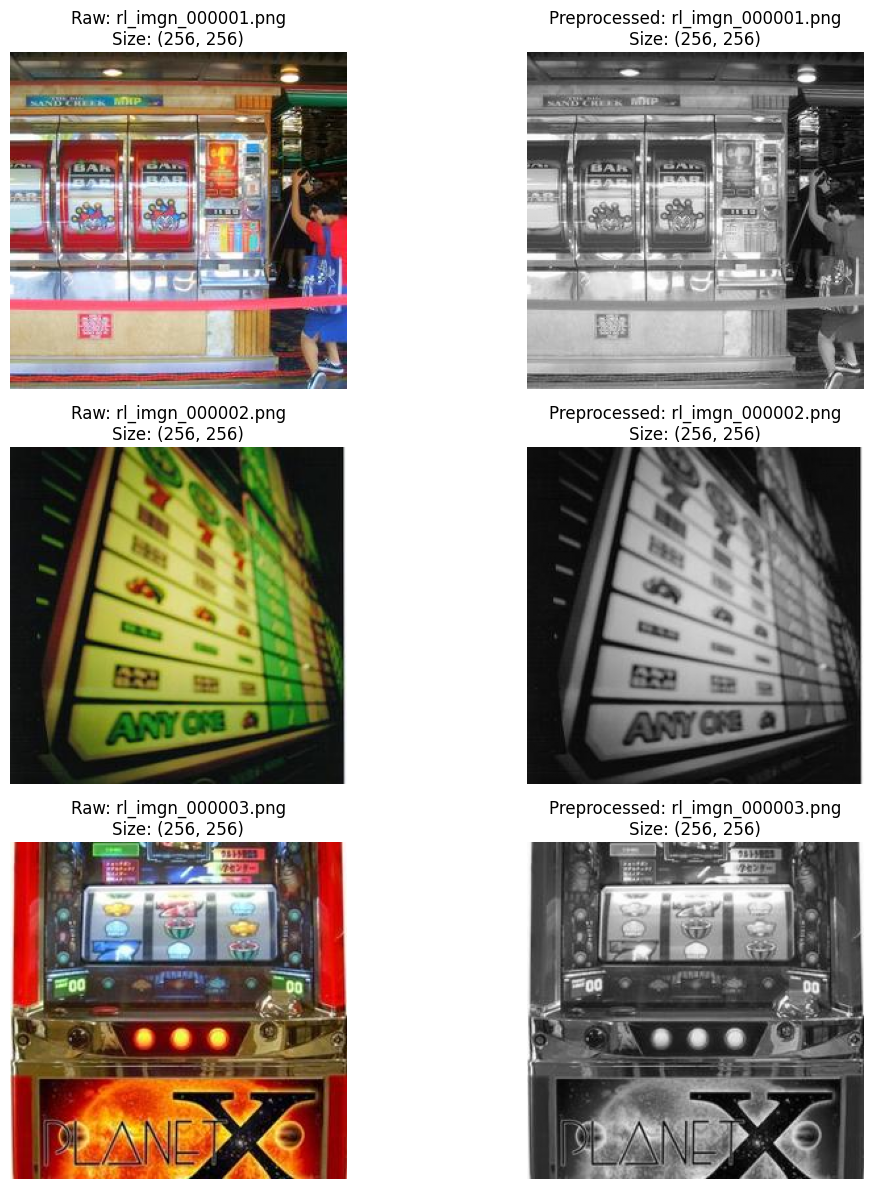

In [ ]:
# ============================================
# Step 10: Raw vs Preprocessed Comparison
# ============================================

import matplotlib.pyplot as plt

# -------------------------------------------------
# Select a few processed images for comparison
# -------------------------------------------------
# Collect processed output image files
preview_files = sorted([
    f for f in os.listdir(processed_image_dir)
    if os.path.isfile(os.path.join(processed_image_dir, f))
    and f.lower().endswith(output_extension)
])

# Limit preview to a small number of examples
num_preview = min(3, len(preview_files))

# -------------------------------------------------
# Handle case where no preview images are available
# -------------------------------------------------
if num_preview == 0:
    print("No processed images available for preview.")

# -------------------------------------------------
# Display raw and preprocessed images side by side
# -------------------------------------------------
else:
    print(f"Displaying {num_preview} raw vs preprocessed image comparisons...\n")

    plt.figure(figsize=(12, 4 * num_preview))

    for i, filename in enumerate(preview_files[:num_preview], start=1):

        # Resolve raw and processed image paths
        raw_path = os.path.join(local_image_dir, filename)
        processed_path = os.path.join(processed_image_dir, filename)

        # -------------------------------------------------
        # Load raw image
        # -------------------------------------------------
        try:
            with Image.open(raw_path) as raw_img:
                raw_img_display = raw_img.copy()
                raw_size = raw_img.size
        except Exception:
            raw_img_display = None
            raw_size = "Unavailable"

        # -------------------------------------------------
        # Load processed image
        # -------------------------------------------------
        try:
            with Image.open(processed_path) as proc_img:
                proc_img_display = proc_img.copy()
                proc_size = proc_img.size
        except Exception:
            proc_img_display = None
            proc_size = "Unavailable"

        # -------------------------------------------------
        # Raw image (left)
        # -------------------------------------------------
        plt.subplot(num_preview, 2, 2 * i - 1)

        if raw_img_display is not None:
            plt.imshow(raw_img_display)
            plt.title(f"Raw: {filename}\nSize: {raw_size}")
        else:
            plt.text(0.5, 0.5, "Raw image load failed", ha="center", va="center")

        plt.axis("off")

        # -------------------------------------------------
        # Preprocessed image (right)
        # -------------------------------------------------
        plt.subplot(num_preview, 2, 2 * i)

        if proc_img_display is not None:
            plt.imshow(proc_img_display, cmap="gray")
            plt.title(f"Preprocessed: {filename}\nSize: {proc_size}")
        else:
            plt.text(0.5, 0.5, "Preprocessed image load failed", ha="center", va="center")

        plt.axis("off")

    # Adjust layout and display comparison figure
    plt.tight_layout()
    plt.show()

